In [1]:
import qiskit
print(qiskit.__version__)

2.5.2


In [2]:
# Qiskit 2.5.2 + Qiskit Aer 0.17.2

import qiskit as qk

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit import ClassicalRegister
from qiskit import transpile

from qiskit_aer import Aer
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram

from math import pi

In [3]:
theta = 0 # all pixels black
qc = QuantumCircuit(3)


qc.h(0)
qc.h(1)

qc.barrier()
#Pixel 1

qc.cry(theta,0,2)
qc.cx(0,1)
qc.cry(-theta,1,2)
qc.cx(0,1)
qc.cry(theta,1,2)

qc.barrier()
#Pixel 2

qc.x(1)
qc.cry(theta,0,2)
qc.cx(0,1)
qc.cry(-theta,1,2)
qc.cx(0,1)
qc.cry(theta,1,2)

qc.barrier()

qc.x(1)
qc.x(0)
qc.cry(theta,0,2)
qc.cx(0,1)
qc.cry(-theta,1,2)
qc.cx(0,1)
qc.cry(theta,1,2)


qc.barrier()

qc.x(1)

qc.cry(theta,0,2)
qc.cx(0,1)
qc.cry(-theta,1,2)
qc.cx(0,1)
qc.cry(theta,1,2)

qc.measure_all()

qc.draw()

┌───┐ ░                                       ░                    »
   q_0: ┤ H ├─░─────■──────■─────────────■────────────░──────────■──────■──»
        ├───┤ ░     │    ┌─┴─┐         ┌─┴─┐          ░ ┌───┐    │    ┌─┴─┐»
   q_1: ┤ H ├─░─────┼────┤ X ├────■────┤ X ├────■─────░─┤ X ├────┼────┤ X ├»
        └───┘ ░ ┌───┴───┐└───┘┌───┴───┐└───┘┌───┴───┐ ░ └───┘┌───┴───┐└───┘»
   q_2: ──────░─┤ Ry(0) ├─────┤ Ry(0) ├─────┤ Ry(0) ├─░──────┤ Ry(0) ├─────»
              ░ └───────┘     └───────┘     └───────┘ ░      └───────┘     »
meas: 3/═══════════════════════════════════════════════════════════════════»
                                                                           »
«                                ░ ┌───┐                                     »
«   q_0: ───────────■────────────░─┤ X ├────■──────■─────────────■───────────»
«                 ┌─┴─┐          ░ ├───┤    │    ┌─┴─┐         ┌─┴─┐         »
«   q_1: ────■────┤ X ├────■─────░─┤ X ├────┼────┤ X ├────■────┤ X ├────■────»
«        ┌───┴───┐└───┘┌───┴───┐ ░ └───┘┌───┴───┐└───┘┌───┴───┐└───┘┌───┴───┐»
«   q_2: ┤ Ry(0) ├─────┤ Ry(0) ├─░──────┤ Ry(0) ├─────┤ Ry(0) ├─────┤ Ry(0) ├»
«        └───────┘     └───────┘ ░      └───────┘     └───────┘     └───────┘»
«meas: 3/════════════════════════════════════════════════════════════════════»
«                                                                            »
«         ░                                            ░ ┌─┐      
«   q_0: ─░──────────■──────■─────────────■────────────░─┤M├──────
«         ░ ┌───┐    │    ┌─┴─┐         ┌─┴─┐          ░ └╥┘┌─┐   
«   q_1: ─░─┤ X ├────┼────┤ X ├────■────┤ X ├────■─────░──╫─┤M├───
«         ░ └───┘┌───┴───┐└───┘┌───┴───┐└───┘┌───┴───┐ ░  ║ └╥┘┌─┐
«   q_2: ─░──────┤ Ry(0) ├─────┤ Ry(0) ├─────┤ Ry(0) ├─░──╫──╫─┤M├
«         ░      └───────┘     └───────┘     └───────┘ ░  ║  ║ └╥┘
«meas: 3/═════════════════════════════════════════════════╩══╩══╩═
«                                                         0  1  2

{'001': 1013, '000': 1049, '010': 984, '011': 1050}


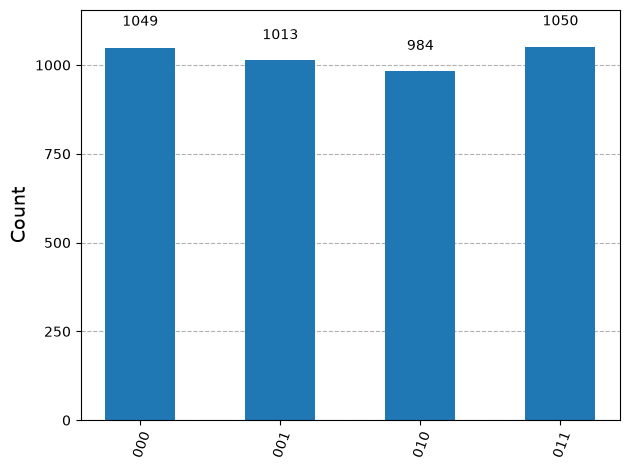

In [4]:
aer_sim = Aer.get_backend('aer_simulator')

t_qc = transpile(qc, aer_sim)

result = aer_sim.run(t_qc, shots=4096).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

In [5]:
pi=90
theta = pi/2  # all pixels white
qc1 = QuantumCircuit(3)

qc1.h(0)
qc1.h(1)

qc1.barrier()
#Pixel 1

qc1.cry(theta,0,2)
qc1.cx(0,1)
qc1.cry(-theta,1,2)
qc1.cx(0,1)
qc1.cry(theta,1,2)

qc1.barrier()
#Pixel 2

qc1.x(1)

qc1.cry(theta,0,2)
qc1.cx(0,1)
qc1.cry(-theta,1,2)
qc1.cx(0,1)
qc1.cry(theta,1,2)

qc1.barrier()

qc1.x(1)
qc1.x(0)
qc1.cry(theta,0,2)
qc1.cx(0,1)
qc1.cry(-theta,1,2)
qc1.cx(0,1)
qc1.cry(theta,1,2)


qc1.barrier()

qc1.x(1)

qc1.cry(theta,0,2)
qc1.cx(0,1)
qc1.cry(-theta,1,2)
qc1.cx(0,1)
qc1.cry(theta,1,2)

qc1.measure_all()

qc1.draw()

┌───┐ ░                                           ░                »
   q_0: ┤ H ├─░─────■───────■───────────────■─────────────░──────────■─────»
        ├───┤ ░     │     ┌─┴─┐           ┌─┴─┐           ░ ┌───┐    │     »
   q_1: ┤ H ├─░─────┼─────┤ X ├─────■─────┤ X ├────■──────░─┤ X ├────┼─────»
        └───┘ ░ ┌───┴────┐└───┘┌────┴────┐└───┘┌───┴────┐ ░ └───┘┌───┴────┐»
   q_2: ──────░─┤ Ry(45) ├─────┤ Ry(-45) ├─────┤ Ry(45) ├─░──────┤ Ry(45) ├»
              ░ └────────┘     └─────────┘     └────────┘ ░      └────────┘»
meas: 3/═══════════════════════════════════════════════════════════════════»
                                                                           »
«                                        ░ ┌───┐                               »
«   q_0: ──■───────────────■─────────────░─┤ X ├────■───────■───────────────■──»
«        ┌─┴─┐           ┌─┴─┐           ░ ├───┤    │     ┌─┴─┐           ┌─┴─┐»
«   q_1: ┤ X ├─────■─────┤ X ├────■──────░─┤ X ├────┼─────┤ X ├─────■─────┤ X ├»
«        └───┘┌────┴────┐└───┘┌───┴────┐ ░ └───┘┌───┴────┐└───┘┌────┴────┐└───┘»
«   q_2: ─────┤ Ry(-45) ├─────┤ Ry(45) ├─░──────┤ Ry(45) ├─────┤ Ry(-45) ├─────»
«             └─────────┘     └────────┘ ░      └────────┘     └─────────┘     »
«meas: 3/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«                   ░                                                ░ ┌─┐   »
«   q_0: ───────────░──────────■───────■───────────────■─────────────░─┤M├───»
«                   ░ ┌───┐    │     ┌─┴─┐           ┌─┴─┐           ░ └╥┘┌─┐»
«   q_1: ────■──────░─┤ X ├────┼─────┤ X ├─────■─────┤ X ├────■──────░──╫─┤M├»
«        ┌───┴────┐ ░ └───┘┌───┴────┐└───┘┌────┴────┐└───┘┌───┴────┐ ░  ║ └╥┘»
«   q_2: ┤ Ry(45) ├─░──────┤ Ry(45) ├─────┤ Ry(-45) ├─────┤ Ry(45) ├─░──╫──╫─»
«        └────────┘ ░      └────────┘     └─────────┘     └────────┘ ░  ║  ║ »
«meas: 3/═══════════════════════════════════════════════════════════════╩══╩═»
«                                                                       0  1 »
«           
«   q_0: ───
«           
«   q_1: ───
«        ┌─┐
«   q_2: ┤M├
«        └╥┘
«meas: 3/═╩═
«         2

{'110': 776, '111': 709, '100': 753, '101': 710, '010': 296, '001': 276, '000': 290, '011': 286}


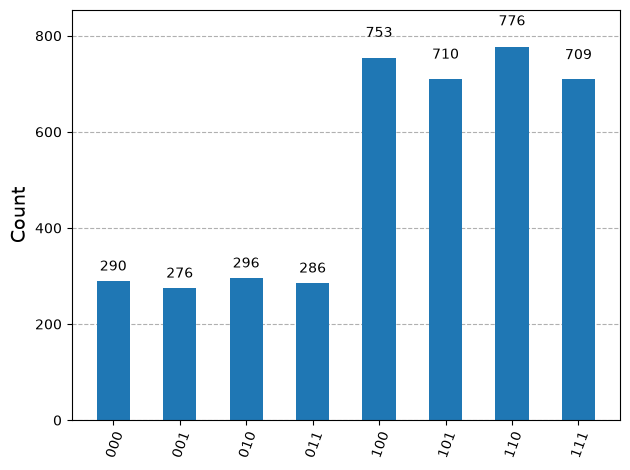

In [6]:
aer_sim = Aer.get_backend('aer_simulator')

t_qc1 = transpile(qc1, aer_sim)

result = aer_sim.run(t_qc1, shots=4096).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

In [7]:
theta = pi/4  # all pixels white
qc2 = qk.QuantumCircuit(3)

qc2.h(0)
qc2.h(1)

qc2.barrier()
#Pixel 1

qc2.cry(theta,0,2)
qc2.cx(0,1)
qc2.cry(-theta,1,2)
qc2.cx(0,1)
qc2.cry(theta,1,2)

qc2.barrier()
#Pixel 2

qc2.x(1)

qc2.cry(theta,0,2)
qc2.cx(0,1)
qc2.cry(-theta,1,2)
qc2.cx(0,1)
qc2.cry(theta,1,2)

qc2.barrier()

qc2.x(1)
qc2.x(0)
qc2.cry(theta,0,2)
qc2.cx(0,1)
qc2.cry(-theta,1,2)
qc2.cx(0,1)
qc2.cry(theta,1,2)


qc2.barrier()

qc2.x(1)

qc2.cry(theta,0,2)
qc2.cx(0,1)
qc2.cry(-theta,1,2)
qc2.cx(0,1)
qc2.cry(theta,1,2)

qc2.measure_all()

qc2.draw()

┌───┐ ░                                                 ░      »
   q_0: ┤ H ├─░──────■────────■─────────────────■───────────────░──────»
        ├───┤ ░      │      ┌─┴─┐             ┌─┴─┐             ░ ┌───┐»
   q_1: ┤ H ├─░──────┼──────┤ X ├──────■──────┤ X ├─────■───────░─┤ X ├»
        └───┘ ░ ┌────┴─────┐└───┘┌─────┴─────┐└───┘┌────┴─────┐ ░ └───┘»
   q_2: ──────░─┤ Ry(22.5) ├─────┤ Ry(-22.5) ├─────┤ Ry(22.5) ├─░──────»
              ░ └──────────┘     └───────────┘     └──────────┘ ░      »
meas: 3/═══════════════════════════════════════════════════════════════»
                                                                       »
«                                                        ░ ┌───┐            »
«   q_0: ─────■────────■─────────────────■───────────────░─┤ X ├─────■──────»
«             │      ┌─┴─┐             ┌─┴─┐             ░ ├───┤     │      »
«   q_1: ─────┼──────┤ X ├──────■──────┤ X ├─────■───────░─┤ X ├─────┼──────»
«        ┌────┴─────┐└───┘┌─────┴─────┐└───┘┌────┴─────┐ ░ └───┘┌────┴─────┐»
«   q_2: ┤ Ry(22.5) ├─────┤ Ry(-22.5) ├─────┤ Ry(22.5) ├─░──────┤ Ry(22.5) ├»
«        └──────────┘     └───────────┘     └──────────┘ ░      └──────────┘»
«meas: 3/═══════════════════════════════════════════════════════════════════»
«                                                                           »
«                                            ░                       »
«   q_0: ──■─────────────────■───────────────░───────────■────────■──»
«        ┌─┴─┐             ┌─┴─┐             ░ ┌───┐     │      ┌─┴─┐»
«   q_1: ┤ X ├──────■──────┤ X ├─────■───────░─┤ X ├─────┼──────┤ X ├»
«        └───┘┌─────┴─────┐└───┘┌────┴─────┐ ░ └───┘┌────┴─────┐└───┘»
«   q_2: ─────┤ Ry(-22.5) ├─────┤ Ry(22.5) ├─░──────┤ Ry(22.5) ├─────»
«             └───────────┘     └──────────┘ ░      └──────────┘     »
«meas: 3/════════════════════════════════════════════════════════════»
«                                                                    »
«                                       ░ ┌─┐      
«   q_0: ───────────────■───────────────░─┤M├──────
«                     ┌─┴─┐             ░ └╥┘┌─┐   
«   q_1: ──────■──────┤ X ├─────■───────░──╫─┤M├───
«        ┌─────┴─────┐└───┘┌────┴─────┐ ░  ║ └╥┘┌─┐
«   q_2: ┤ Ry(-22.5) ├─────┤ Ry(22.5) ├─░──╫──╫─┤M├
«        └───────────┘     └──────────┘ ░  ║  ║ └╥┘
«meas: 3/══════════════════════════════════╩══╩══╩═
«                                          0  1  2

{'011': 769, '110': 252, '000': 769, '101': 265, '100': 248, '001': 768, '010': 784, '111': 241}


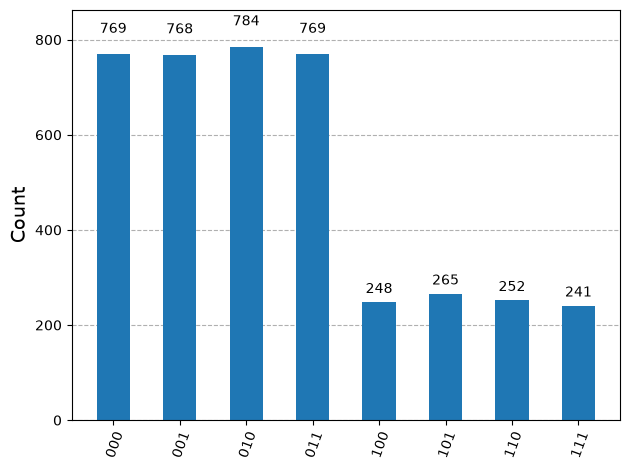

In [8]:
aer_sim = Aer.get_backend('aer_simulator')

t_qc2 = transpile(qc2, aer_sim)

result = aer_sim.run(t_qc2, shots=4096).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

In [9]:
print("Depth: ", qc1.depth())
print("Operations: ", qc1.count_ops())

Depth:  23
Operations:  OrderedDict({'cry': 12, 'cx': 8, 'barrier': 5, 'x': 4, 'measure': 3, 'h': 2})


In [10]:
from qiskit import transpile

new_circ = transpile(
    qc1,
    basis_gates=['u', 'cx'],
    optimization_level=0
)

new_circ.draw()

┌────────────┐ ░                                          »
   q_0: ┤ U(π/2,0,π) ├─░──────────────────■────────────────────■──»
        ├────────────┤ ░                  │                    │  »
   q_1: ┤ U(π/2,0,π) ├─░──────────────────┼────────────────────┼──»
        └────────────┘ ░ ┌─────────────┐┌─┴─┐┌──────────────┐┌─┴─┐»
   q_2: ───────────────░─┤ U(22.5,0,0) ├┤ X ├┤ U(-22.5,0,0) ├┤ X ├»
                       ░ └─────────────┘└───┘└──────────────┘└───┘»
meas: 3/══════════════════════════════════════════════════════════»
                                                                  »
«                                                                     »
«   q_0: ───────■────────────────────────────────────────■────────────»
«             ┌─┴─┐                                    ┌─┴─┐          »
«   q_1: ─────┤ X ├────────■───────────────────■───────┤ X ├───────■──»
«        ┌────┴───┴─────┐┌─┴─┐┌─────────────┐┌─┴─┐┌────┴───┴────┐┌─┴─┐»
«   q_2: ┤ U(-22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├»
«        └──────────────┘└───┘└─────────────┘└───┘└─────────────┘└───┘»
«meas: 3/═════════════════════════════════════════════════════════════»
«                                                                     »
«                              ░                                          »
«   q_0: ──────────────────────░──────────────────■────────────────────■──»
«                              ░   ┌──────────┐   │                    │  »
«   q_1: ──────────────────■───░───┤ U(π,0,π) ├───┼────────────────────┼──»
«        ┌──────────────┐┌─┴─┐ ░ ┌─┴──────────┴┐┌─┴─┐┌──────────────┐┌─┴─┐»
«   q_2: ┤ U(-22.5,0,0) ├┤ X ├─░─┤ U(22.5,0,0) ├┤ X ├┤ U(-22.5,0,0) ├┤ X ├»
«        └──────────────┘└───┘ ░ └─────────────┘└───┘└──────────────┘└───┘»
«meas: 3/═════════════════════════════════════════════════════════════════»
«                                                                         »
«                                                                     »
«   q_0: ───────■────────────────────────────────────────■────────────»
«             ┌─┴─┐                                    ┌─┴─┐          »
«   q_1: ─────┤ X ├────────■───────────────────■───────┤ X ├───────■──»
«        ┌────┴───┴─────┐┌─┴─┐┌─────────────┐┌─┴─┐┌────┴───┴────┐┌─┴─┐»
«   q_2: ┤ U(-22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├»
«        └──────────────┘└───┘└─────────────┘└───┘└─────────────┘└───┘»
«meas: 3/═════════════════════════════════════════════════════════════»
«                                                                     »
«                              ░   ┌──────────┐                           »
«   q_0: ──────────────────────░───┤ U(π,0,π) ├───■────────────────────■──»
«                              ░   ├──────────┤   │                    │  »
«   q_1: ──────────────────■───░───┤ U(π,0,π) ├───┼────────────────────┼──»
«        ┌──────────────┐┌─┴─┐ ░ ┌─┴──────────┴┐┌─┴─┐┌──────────────┐┌─┴─┐»
«   q_2: ┤ U(-22.5,0,0) ├┤ X ├─░─┤ U(22.5,0,0) ├┤ X ├┤ U(-22.5,0,0) ├┤ X ├»
«        └──────────────┘└───┘ ░ └─────────────┘└───┘└──────────────┘└───┘»
«meas: 3/═════════════════════════════════════════════════════════════════»
«                                                                         »
«                                                                     »
«   q_0: ───────■────────────────────────────────────────■────────────»
«             ┌─┴─┐                                    ┌─┴─┐          »
«   q_1: ─────┤ X ├────────■───────────────────■───────┤ X ├───────■──»
«        ┌────┴───┴─────┐┌─┴─┐┌─────────────┐┌─┴─┐┌────┴───┴────┐┌─┴─┐»
«   q_2: ┤ U(-22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├┤ U(22.5,0,0) ├┤ X ├»
«        └──────────────┘└───┘└─────────────┘└───┘└─────────────┘└───┘»
«meas: 3/═════════════════════════════════════════════════════════════»
«                                                                     »
«                              ░                                          »
«   q_0:

In [11]:
print("Depth : ", new_circ.depth())
print("Operations: ", new_circ.count_ops())

Depth :  50
Operations:  OrderedDict({'cx': 32, 'u': 30, 'barrier': 5, 'measure': 3})


In [13]:
import qiskit_ibm_runtime.fake_provider as fp

fake_backends = [name for name in dir(fp) if name.startswith("Fake")]
print(fake_backends)

['FakeAachen', 'FakeAlgiers', 'FakeAlmadenV2', 'FakeArmonkV2', 'FakeAthensV2', 'FakeAuckland', 'FakeBelemV2', 'FakeBerlin', 'FakeBoeblingenV2', 'FakeBogotaV2', 'FakeBoston', 'FakeBrisbane', 'FakeBrooklynV2', 'FakeBrussels', 'FakeBurlingtonV2', 'FakeCairoV2', 'FakeCambridgeV2', 'FakeCasablancaV2', 'FakeCusco', 'FakeEssexV2', 'FakeFez', 'FakeFractionalBackend', 'FakeGeneva', 'FakeGuadalupeV2', 'FakeHanoiV2', 'FakeJakartaV2', 'FakeJohannesburgV2', 'FakeKawasaki', 'FakeKingston', 'FakeKolkataV2', 'FakeKyiv', 'FakeKyoto', 'FakeLagosV2', 'FakeLimaV2', 'FakeLondonV2', 'FakeManhattanV2', 'FakeManilaV2', 'FakeMarrakesh', 'FakeMelbourneV2', 'FakeMiami', 'FakeMontrealV2', 'FakeMumbaiV2', 'FakeNairobiV2', 'FakeNighthawk', 'FakeOsaka', 'FakeOslo', 'FakeOurenseV2', 'FakeParisV2', 'FakePeekskill', 'FakePerth', 'FakePittsburgh', 'FakePoughkeepsieV2', 'FakePrague', 'FakeProviderForBackendV2', 'FakeQuebec', 'FakeQuitoV2', 'FakeRochesterV2', 'FakeRomeV2', 'FakeSantiagoV2', 'FakeSherbrooke', 'FakeSingapor

In [14]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeAthensV2

fake_athens = FakeAthensV2()

optimized_3 = transpile(
    qc1,
    backend=fake_athens,
    seed_transpiler=11,
    optimization_level=3
)

print("gates =", optimized_3.count_ops())
print("depth =", optimized_3.depth())

gates = OrderedDict({'rz': 56, 'cx': 49, 'sx': 26, 'x': 18, 'barrier': 5, 'measure': 3})
depth = 116


{'100': 725, '010': 300, '101': 757, '110': 730, '001': 286, '111': 728, '000': 293, '011': 277}


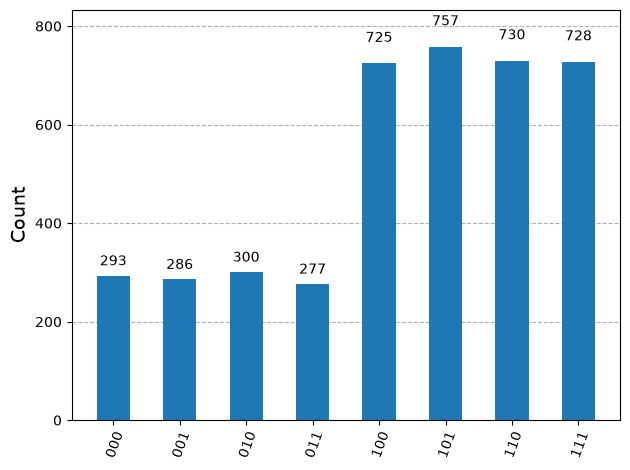

In [15]:
from qiskit import transpile
from qiskit_aer import AerSimulator

t_qc1 = transpile(
    qc1,
    backend=fake_athens,
    optimization_level=3
)

simulator = AerSimulator()

result = simulator.run(
    t_qc1,
    shots=4096
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

{'101': 711, '001': 319, '110': 691, '010': 293, '111': 749, '100': 769, '011': 286, '000': 278}


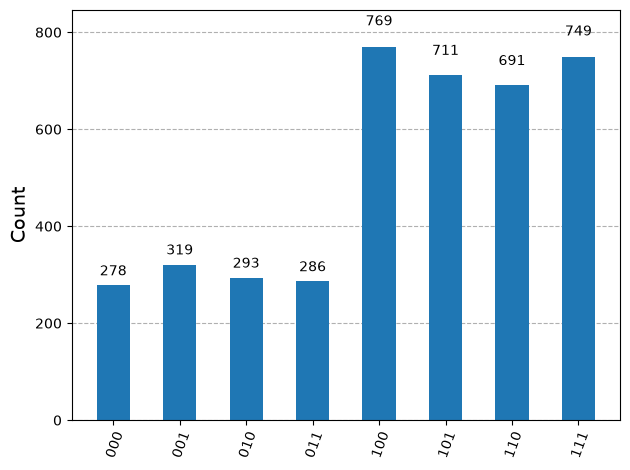

In [16]:
aer_sim = Aer.get_backend('aer_simulator')

result = aer_sim.run(
    t_qc1,
    shots=4096
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)